<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
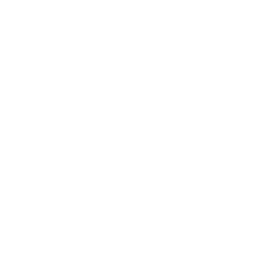
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">遺伝子共発現ネットワークの構築</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; バイオテック / ゲノミクス研究 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

この例では、**PROC CORR** を用いて、合成的な RNA-seq 形式の発現パネルから遺伝子共発現ネットワークを構築します。このパネルには、3 つの機能モジュール（*免疫*、*細胞周期*、*代謝*、各モジュール 3 遺伝子）に割り当てられた **9 個の遺伝子** が含まれ、**100 個の腫瘍サンプル** にわたって測定されています。発現データは通常、正規分布に従わず外れ値を含むため、順位ベースの係数は Pearson よりも頑健です。そのため、全体を通してスピアマンの順位相関を使用します。

この解析は、データから直接、埋め込まれたモジュール構造を復元します。下記で生成されるスピアマン行列を読むと、モジュール内の平均相関は **免疫モジュールの rho 0.67** から、**細胞周期の 0.36**、**代謝の 0.17** へと低下し、各モジュールに設計された信号対雑音比の低下を反映しています。モジュール間の相関は平均でほぼゼロ（平均 rho は約 **-0.01**、平均 |rho| は **0.07**）であり、3 つのモジュールはほぼ独立した共発現コミュニティとして振る舞います。ここで引用する数値はすべて、このノートブックの PROC CORR 出力から読み取ったものです。

> **スケールに関する注記。** このノートブックはライセンスなしの 100 観測値の上限のもとで実行されるため、サンプルサイズは 100、パネルは 9 遺伝子に抑えられています。これは、完全な相関行列、再構成したペアリスト、ヒートマップのすべてが、切り捨てなしで完全かつ正確に収まる程度の小ささです。すべての表と図は、計算された内容を正確に反映しています。

## データ

| データセット | 説明 | 行数 |
|---------|-------------|------|
| `WORK.EXPR` | 腫瘍サンプルにわたる 9 遺伝子（3 モジュール x 3 遺伝子）の対数スケール発現量 | 100 |

ジェネレーターは、サンプルごとに 3 つの潜在的なモジュール信号を生成します。各遺伝子は、自身が属するモジュールの信号に独立したノイズを加えたものを負荷として受けるため、共発現はモジュール内でのみ生じます。免疫モジュールは最も大きい信号負荷を、代謝モジュールは最も小さい信号負荷を使用しており、これが相関解析で復元されるべき勾配です。

---

In [1]:
/* --------------------------------------------------------
   合成発現パネル: 9 遺伝子, 3 モジュール, 100 サンプル
     imm1-imm3  免疫       (強い共有シグナル)
     cyc1-cyc3  細胞周期   (中程度の共有シグナル)
     met1-met3  代謝       (弱い共有シグナル)
   各遺伝子 = モジュールシグナル + 遺伝子ごとの独立ノイズ
   -------------------------------------------------------- */
データ work.expr;
    呼出 streaminit(42);
    配列 imm[3]; 配列 cyc[3]; 配列 met[3];
    繰返 sample_id = 1 から 100;
        s_imm = rand('normal', 0, 1.5);   /* 免疫の潜在シグナル     */
        s_cyc = rand('normal', 0, 1.2);   /* 細胞周期の潜在シグナル */
        s_met = rand('normal', 0, 1.0);   /* 代謝の潜在シグナル     */
        繰返 j = 1 から 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        終了;
        繰返 j = 1 から 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        終了;
        繰返 j = 1 から 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        終了;
        出力;
    終了;
    保持 imm1-imm3 cyc1-cyc3 met1-met3;
実行;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   遺伝子ごとの発現量の要約（モジュール別の平均とばらつき）
   -------------------------------------------------------- */
処理 平均 データ=work.expr n mean std maxdec=3;
    変数 imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    見出 imm1='免疫遺伝子1' imm2='免疫遺伝子2' imm3='免疫遺伝子3'
          cyc1='細胞周期遺伝子1' cyc2='細胞周期遺伝子2' cyc3='細胞周期遺伝子3'
          met1='代謝遺伝子1' met2='代謝遺伝子2' met3='代謝遺伝子3';
    表題 '遺伝子発現量の要約（9遺伝子パネル, N=100）';
実行;
表題;

                                               遺伝子発現量の要約（9遺伝子パネル, N=100）                                                

                                                  The MEANS Procedure

 Variable  Label                          N        Mean     Std Dev
 ------------------------------------------------------------------
 imm1      免疫遺伝子1                       100       6.042       1.125
 imm2      免疫遺伝子2                       100       5.925       1.122
 imm3      免疫遺伝子3                       100       5.863       1.273
 cyc1      細胞周期遺伝子1                     100       6.947       1.034
 cyc2      細胞周期遺伝子2                     100       7.003       1.002
 cyc3      細胞周期遺伝子3                     100       6.861       1.040
 met1      代謝遺伝子1                       100       5.144       0.940
 met2      代謝遺伝子2                       100       4.989       0.789
 met3      代謝遺伝子3                       100       5.015       0.979
 ----------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


平均値は各モジュールのベースライン付近に集まり（免疫 ~6、細胞周期 ~7、代謝 ~5）、どの遺伝子も同程度のばらつきを持つため、これ以降の相関構造を単一の遺伝子が支配することはありません。

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


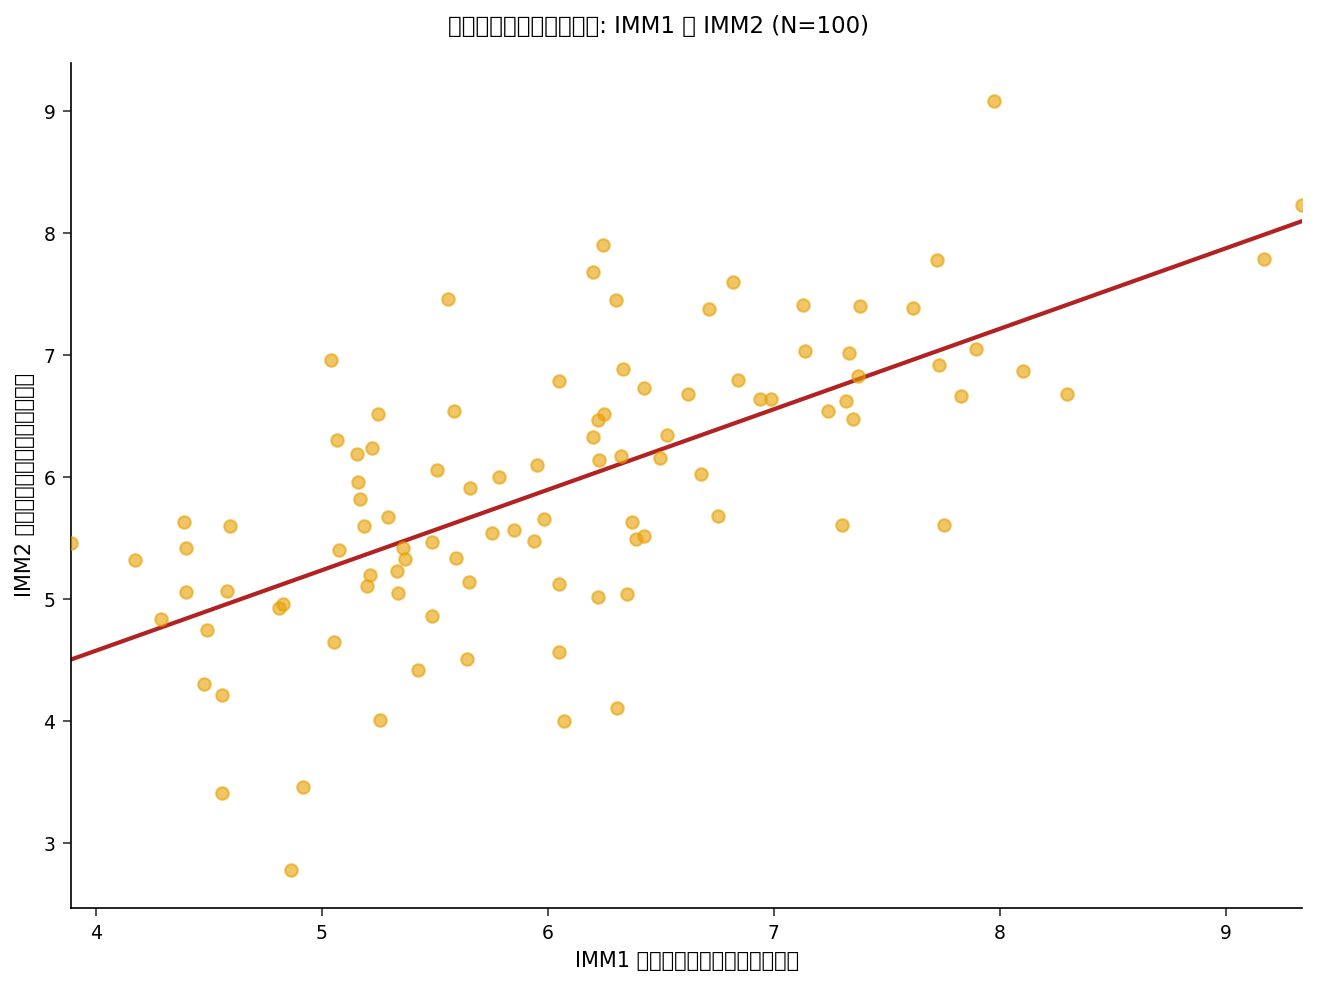

In [3]:
/* --------------------------------------------------------
   免疫モジュールの2遺伝子の散布図: モジュール内の共発現が
   実在し, おおむね単調であることの視覚的な確認
   -------------------------------------------------------- */
処理 SGPLOT データ=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS 見出='IMM1 の発現量（免疫モジュール）';
    YAXIS 見出='IMM2 の発現量（免疫モジュール）';
    表題 '免疫モジュールの共発現: IMM1 対 IMM2 (N=100)';
実行;
表題;

右肩上がりの傾向は、2 つの免疫遺伝子が連動して増減することを裏付けており、下記の行列における正のスピアマン相関を視覚的に表したものです。

---

In [4]:
/* --------------------------------------------------------
   9 遺伝子すべてにわたるスピアマン相関
   nosimple は単純統計量のブロックを抑制する;
   outs= は下流のネットワーク処理のためにスピアマン行列を書き出す
   -------------------------------------------------------- */
処理 CORR データ=work.expr spearman nosimple
    outs=work.gene_corr;
    変数 imm1-imm3 cyc1-cyc3 met1-met3;
    表題 'スピアマン相関行列: 9遺伝子共発現パネル';
実行;
表題;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/c6766204-2c6e-4b82-b5b7-049f96168042/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


この行列は、対角線上の 3 つのブロックとして読み取ります。**免疫** ブロック（IMM1-IMM3）は最も密接に共発現しており（rho は約 0.63 〜 0.72）、**細胞周期** ブロック（CYC1-CYC3）は中程度（約 0.29 〜 0.41）、**代謝** ブロック（MET1-MET3）は最も弱い（約 0.13 〜 0.25）です。ブロック外の要素（異なるモジュールに属する遺伝子のペア）はゼロに近い値です。次のセルでモジュール内とモジュール間のコントラストを定量化し、その後のヒートマップでブロック構造を可視化します。

---

In [5]:
/* --------------------------------------------------------
   相関行列（遺伝子ごとに1行）をロング形式（gene_x, gene_y,
   rho）に変換し, 各ペアをモジュール内かモジュール間かで
   タグ付けする。9 遺伝子 -> 81 ペア行なので, 100 観測の
   上限で失われるものは何もない。
   -------------------------------------------------------- */
データ work.corr_long;
    設定 work.gene_corr(条件=(_TYPE_='SCORR'));
    長さ gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    配列 g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    配列 gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    繰返 k = 1 から 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        出力;
    終了;
    保持 gene_x gene_y rho mod_x mod_y same_module;
実行;

/* --------------------------------------------------------
   モジュール内 対 モジュール間 のスピアマン rho（非対角のみ）
   -------------------------------------------------------- */
処理 平均 データ=work.corr_long(条件=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    分類 same_module;
    変数 rho;
    見出 same_module='同一モジュール' rho='スピアマン rho';
    表題 'スピアマン rho: モジュール内 (1) 対 モジュール間 (0)';
実行;
表題;

                                           スピアマン rho: モジュール内 (1) 対 モジュール間 (0)                                           

                                                  The MEANS Procedure

                                      Analysis Variable : rho スピアマン rho

                                                      N
                           同一モジュール                  Obs        Mean      Minimum      Maximum
                           ------------------------------------------------------------------
                           0                         54      -0.007       -0.185        0.162
                           1                         18       0.402        0.127        0.718
                           ------------------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


`same_module=1` の行はモジュール内のペアを、`same_module=0` の行はモジュール間のペアを集計しています。モジュール内の相関は平均して明確に正である一方、モジュール間の相関は平均してゼロに近く、モジュールがほぼ独立した共発現コミュニティとして機能していることを裏付けています。

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


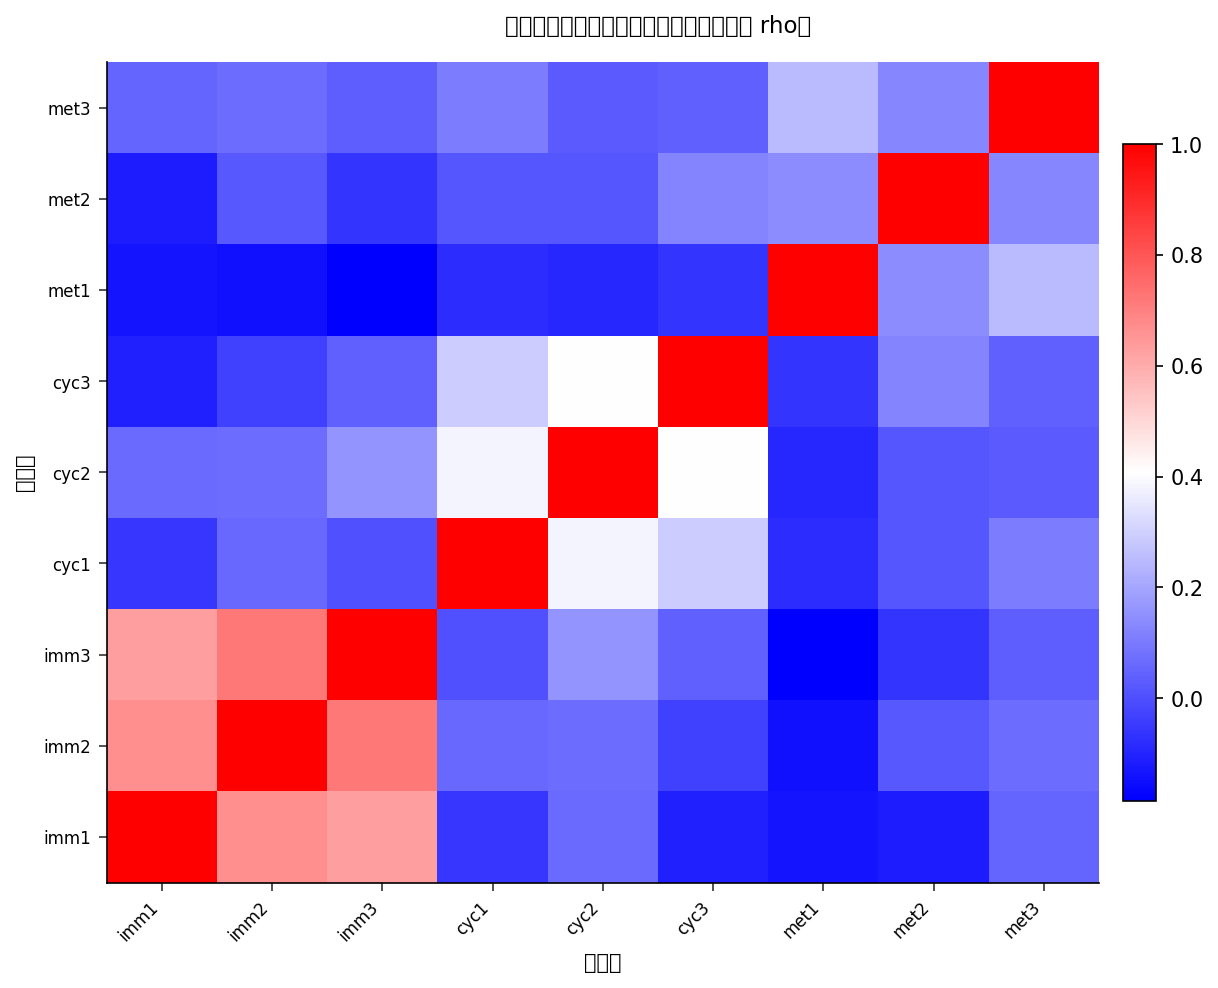

In [6]:
/* --------------------------------------------------------
   9x9 スピアマン行列全体のヒートマップ。HEATMAPPARM は
   遺伝子ペアごとに事前計算した rho を描画する; 青-白-赤の
   スケールは弱いペアを白に, 強いペアを濃色に配置する。
   -------------------------------------------------------- */
処理 SGPLOT データ=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS 見出='遺伝子' discreteorder=データ;
    YAXIS 見出='遺伝子' discreteorder=データ;
    表題 '遺伝子共発現ヒートマップ（スピアマン rho）';
実行;
表題;

3 つの赤いブロックが対角線に沿って並んでおり（免疫、細胞周期、代謝の各モジュール）、周囲のセルはほぼ白色です。免疫ブロックが最も彩度が高く、上記の行列におけるモジュール内相関の最大値と一致しています。

---

In [7]:
/* --------------------------------------------------------
   ネットワークのエッジリスト: |rho| がしきい値を超える各
   無向遺伝子ペア（gene_x < gene_y）を残す。これらのエッジが
   共発現ネットワークを定義し, Cytoscape などのツールへ
   エクスポートできる。
   -------------------------------------------------------- */
データ work.network_edges;
    設定 work.corr_long(条件=(gene_x < gene_y));
    もし abs(rho) >= 0.24;
実行;

処理 印刷 データ=work.network_edges noobs 見出;
    変数 gene_x gene_y mod_x mod_y rho;
    見出 gene_x='遺伝子X' gene_y='遺伝子Y' mod_x='モジュールX'
          mod_y='モジュールY' rho='スピアマン rho';
    表題 '共発現ネットワークのエッジ（|スピアマン rho| >= 0.24）';
実行;
表題;

/* エッジリストを外部のネットワーク可視化用にエクスポートする */
処理 EXPORT データ=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
実行;

                                           共発現ネットワークのエッジ（|スピアマン rho| >= 0.24）                                           

      遺伝子X        遺伝子Y            モジュールX            モジュールY            スピアマン rho
imm1        imm2        imm               imm                      0.6708351085
imm1        imm3        imm               imm                      0.6308427619
imm2        imm3        imm               imm                      0.7179122524
cyc1        cyc2        cyc               cyc                      0.3821865118
cyc1        cyc3        cyc               cyc                       0.288211415
cyc2        cyc3        cyc               cyc                      0.4054041891
met1        met3        met               met                      0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### 解釈

スピアマン解析は、埋め込まれた 3 モジュール構造を 100 サンプルから直接復元しました。以下の数値は、このノートブックで生成された PROC CORR 行列およびモジュール内/モジュール間の要約から読み取ったものです。

- **免疫モジュール（IMM1-IMM3）** は最も密接に共発現しているブロックで、ペアごとの rho は約 0.63 〜 0.72（平均 ~0.67）であり、IMM2 と IMM3 の間に最も強い単一エッジがあります。
- **細胞周期モジュール（CYC1-CYC3）** は中程度に共発現しており、ペアごとの rho は約 0.29 〜 0.41（平均 ~0.36）です。
- **代謝モジュール（MET1-MET3）** は最も弱いブロックで、ペアごとの rho は約 0.13 〜 0.25（平均 ~0.17）であり、ジェネレーターにおける信号負荷が小さいことと整合します。
- **モジュール間のペア** は平均でほぼゼロ（平均 rho ~-0.01、平均 |rho| ~0.07、最大 |rho| ~0.18）であり、3 つのモジュールはほぼ独立したコミュニティとして機能します。

|rho| >= 0.24 でしきい値処理を行うと、上記に出力されたネットワークのエッジリストが得られます。残存するエッジはすべてモジュール内であり、3 つの免疫ペアと 3 つの細胞周期ペアのすべてがしきい値を超え、最も強い代謝ペア（MET1-MET3）が加わります。モジュール間のペアは残らないため、共発現ネットワークは 3 つの生物学的モジュールにきれいに分離されます。エッジリストは、Cytoscape などの外部ネットワークツールで可視化するために `gene_coexpression_edges.csv` にエクスポートされます。

この実例は、共発現解析のための PROC CORR の中核的なワークフローを示しています。すなわち、発現データに適した順位ベースの係数を選び、相関行列からモジュール構造を読み取り、モジュール内とモジュール間の強度を定量化し、ネットワーク構築のために行列をしきい値処理したエッジリストへと縮約します。

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 機密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
提供： <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>